# Titanic Survival — Exploratory Data Analysis

**Goal.** Understand the Kaggle Titanic training data well enough to justify every
preprocessing and modelling choice made in `src/titanic/`, and to establish a realistic
expectation band for model performance *before* any model is trained.

**Ground rules for this notebook**

1. **Only `train.csv`.** `test.csv` and `gender_submission.csv` are never downloaded or read.
2. **Split first, explore second.** The 80/20 stratified split happens in the very first
   analysis cell, and everything below looks at the **training split only** (n = 712). The
   179 held-out rows are not plotted, not summarised, and not used to choose anything. This
   is stricter than most EDA notebooks: looking at the validation set biases the *analyst*,
   which is a real, if unquantifiable, form of leakage.
3. **No feature logic is written here.** Every engineered column comes from
   `titanic.features.engineer`, so this notebook and the training pipeline cannot disagree.

Each section below is one block: **Question → Analysis → Finding → Decision.**

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from titanic.config import TARGET_COLUMN, Paths, SplitConfig
from titanic.data import load_csv, stratified_split, validate_schema
from titanic.features import engineer
from titanic.utils import set_seed

# One seed for the whole notebook: the split below, and the cross-validation
# at the end, must reproduce exactly on a reviewer's machine.
set_seed(42)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.autolayout"] = True
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 20)
warnings.filterwarnings("ignore", category=FutureWarning)

paths = Paths()

# The full train.csv is git-ignored (fetched with `python -m titanic.data --fetch`).
# Fall back to the committed 100-row sample so this notebook runs immediately
# after a clone, with a clear warning that the numbers will be small-sample.
if paths.train_csv.exists():
    csv_path, using_full_data = paths.train_csv, True
else:
    csv_path, using_full_data = paths.sample_csv, False
    print("WARNING: data/train.csv not found - using the 100-row sample.")
    print("         Run `python -m titanic.data --fetch` for the real analysis.\n")

raw = load_csv(csv_path)
validate_schema(raw, require_target=True)
print(f"Loaded {csv_path.name}: {raw.shape[0]} rows x {raw.shape[1]} columns")

17:01:19 | INFO    | titanic.data | Loaded train.csv: 891 rows x 12 columns


Loaded train.csv: 891 rows x 12 columns


---

## 1. Split before looking

**Question.** What data am I allowed to look at?

**Analysis.** Create the same stratified 80/20 split the training pipeline uses — same
function, same seed — and discard the validation half for the rest of this notebook.

In [2]:
train_raw, val_raw = stratified_split(raw, SplitConfig())

# `df` is the ONLY frame used below. `val_raw` is deliberately left untouched.
df = engineer(train_raw)
del val_raw

print(f"training split : {len(train_raw)} rows  <- everything below uses this")
print(f"held-out split : {len(raw) - len(train_raw)} rows  <- not inspected in this notebook")
print(f"\nengineered columns added: {[c for c in df.columns if c not in raw.columns]}")

17:01:19 | INFO    | titanic.data | Split: train=712 (38.3% positive), val=179 (38.5% positive)


training split : 712 rows  <- everything below uses this
held-out split : 179 rows  <- not inspected in this notebook

engineered columns added: ['Title', 'FamilySize', 'IsAlone', 'Deck', 'LogFare']


**Finding.** 712 training rows, 179 held out. The engineered columns (`Title`, `FamilySize`,
`IsAlone`, `Deck`, `LogFare`) come from `titanic.features.engineer` — not re-implemented here.

**Decision.** All statistics, plots and the cross-validation below are computed on the 712-row
training split. The held-out set is scored exactly once, in `train.py`, at the end.

---

## 2. Shape, types and target balance

**Question.** What are we predicting, and how imbalanced is it?

**Analysis.** Column types and the survival rate.

In [3]:
summary = pd.DataFrame(
    {
        "dtype": train_raw.dtypes.astype(str),
        "non_null": train_raw.notna().sum(),
        "missing": train_raw.isna().sum(),
        "missing_%": (100 * train_raw.isna().mean()).round(1),
        "n_unique": train_raw.nunique(),
    }
)
display(summary)

base_rate = df[TARGET_COLUMN].mean()
counts = df[TARGET_COLUMN].value_counts().sort_index()
print(f"\nSurvived = 0 : {counts.get(0, 0):>4}")
print(f"Survived = 1 : {counts.get(1, 0):>4}")
print(f"base rate    : {base_rate:.4f}  ({base_rate:.1%} survived)")
print(f"\nMajority-class baseline accuracy: {max(base_rate, 1 - base_rate):.3f}")

,dtype,non_null,missing,missing_%,n_unique
PassengerId,int64,712,0,0.0,712
Survived,int64,712,0,0.0,2
Pclass,int64,712,0,0.0,3
Name,object,712,0,0.0,712
Sex,object,712,0,0.0,2
Age,float64,575,137,19.2,85
SibSp,int64,712,0,0.0,7
Parch,int64,712,0,0.0,7
Ticket,object,712,0,0.0,571
Fare,float64,712,0,0.0,226



Survived = 0 :  439
Survived = 1 :  273
base rate    : 0.3834  (38.3% survived)

Majority-class baseline accuracy: 0.617


**Finding.** Roughly **38% survived**, so the classes are moderately imbalanced. A model that
predicts "nobody survived" scores about **0.62 accuracy** while being completely useless.

**Decision.** Accuracy alone is not an acceptable headline metric. The project reports
accuracy, precision, recall, F1, ROC-AUC **and PR-AUC**, because PR-AUC is far more sensitive
to performance on the minority (survived) class — which is the class a user of this model
actually cares about. Every metric is reported with a bootstrap confidence interval, because
n = 179 in the held-out set is small enough that three decimal places would be dishonest.

---

## 3. Missingness

**Question.** Which columns have holes, how big, and what should fill them?

**Analysis.** *(Figure 1 of 7)*

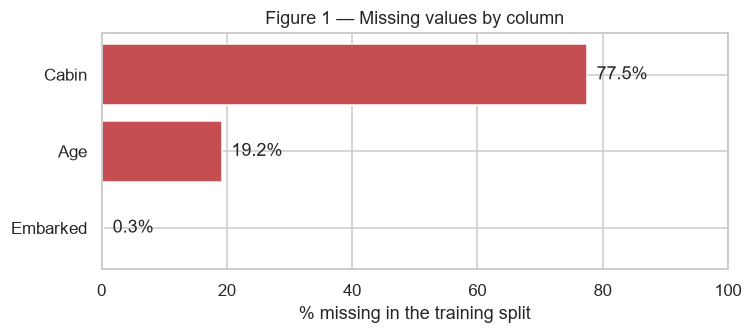

Cabin       77.5
Age         19.2
Embarked     0.3


In [4]:
missing_pct = (100 * train_raw.isna().mean()).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh(missing_pct.index[::-1], missing_pct.to_numpy()[::-1], color="#c44e52")
ax.set_xlabel("% missing in the training split")
ax.set_title("Figure 1 — Missing values by column")
ax.set_xlim(0, 100)
for bar, value in zip(bars, missing_pct.to_numpy()[::-1], strict=True):
    ax.text(value + 1.5, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center")
plt.show()

print(missing_pct.round(1).to_string())

**Finding.** Three columns have holes, and they need three different treatments:

| column | missing | why it is missing | treatment |
|---|---|---|---|
| `Cabin` | ~77% | not recorded for most; *who* was recorded tracks class | keep as a level |
| `Age` | ~20% | not recorded | impute — but not with one global number |
| `Embarked` | 2 rows | clerical gap | impute with the mode |

**Decision.**
- `Cabin` → `Deck` = first letter, missing → **`U`** as its own category. Not having a recorded
  cabin is itself informative (it correlates with lower class and lower survival), so throwing
  the rows away or imputing a deck would destroy real signal. This also removes the need for a
  separate `HasCabin` flag — `Deck == "U"` already is one.
- `Age` → **median per `Title`**, justified in section 5 below.
- `Embarked` → mode (`S`, Southampton, ~72% of passengers). Two rows do not deserve more.

All three values are **fitted on the training split and serialised** to
`artifacts/<model>/preprocessor.json`; nothing is recomputed at inference time.

---

## 4. Duplicates, and the features we deliberately refuse to use

**Question.** Are there duplicate rows? And what about the group features that top the Kaggle
leaderboards — ticket-group size and fare-per-person?

**Analysis.** No figure; this is an argument, not a picture.

In [5]:
feature_cols = [c for c in train_raw.columns if c not in ("PassengerId", TARGET_COLUMN)]
n_duplicates = train_raw.duplicated(subset=feature_cols).sum()
print(f"exact duplicate rows (ignoring PassengerId): {n_duplicates}")

# How strong would the tempting batch-dependent feature be?
ticket_group = train_raw.groupby("Ticket")["Ticket"].transform("size")
shared = (ticket_group > 1).mean()
print(f"passengers sharing a ticket with someone else: {shared:.1%}")

survival_by_group = (
    train_raw.assign(TicketGroupSize=ticket_group)
    .groupby("TicketGroupSize")[TARGET_COLUMN]
    .agg(["mean", "size"])
    .rename(columns={"mean": "survival_rate", "size": "n"})
)
display(survival_by_group.head(8).round(3))

# The decisive test: what is this feature worth for ONE passenger at inference?
one_passenger = train_raw.iloc[[0]]
print(f"\nTicketGroupSize computed on a single-row request: "
      f"{one_passenger.groupby('Ticket')['Ticket'].transform('size').iloc[0]}")
print(f"The same passenger's true value in the training batch: {ticket_group.iloc[0]}")

exact duplicate rows (ignoring PassengerId): 0
passengers sharing a ticket with someone else: 33.1%


,survival_rate,n
TicketGroupSize,,
1,0.317,476
2,0.623,138
3,0.595,42
4,0.250,24
5,0.000,20
6,0.417,12



TicketGroupSize computed on a single-row request: 1
The same passenger's true value in the training batch: 6


**Finding.** No duplicate rows. Ticket-group size *does* carry signal — survival varies
strongly with group size — but the last two lines of output show the problem: the same
passenger has group size **1** when scored alone and a different value when scored inside a
batch. The feature's meaning depends on which other rows happen to be in the file.

**Decision.** `TicketGroupSize` and `FarePerPerson` are **excluded**, and
`tests/test_features.py::test_does_not_add_batch_dependent_features` keeps them out. Two
independent reasons:

1. **Train/serve skew.** The value at inference is not the value the model trained on.
2. **Leakage within training.** Group size is a proxy for "did other members of this family
   survive", which smuggles label information across rows of the same group.

*Alternative considered:* fit a ticket → count lookup on the training split and default unseen
tickets to 1. Technically leak-safe, but semantically brittle, and it fails the moment a real
passenger has a ticket the training set never saw. Rejected; recorded in `docs/DECISIONS.md`.

---

## 5. The dominant effect: sex, class, and their interaction

**Question.** Which raw variables actually separate survivors, and do they act independently?

**Analysis.** *(Figure 2 of 7)*

17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


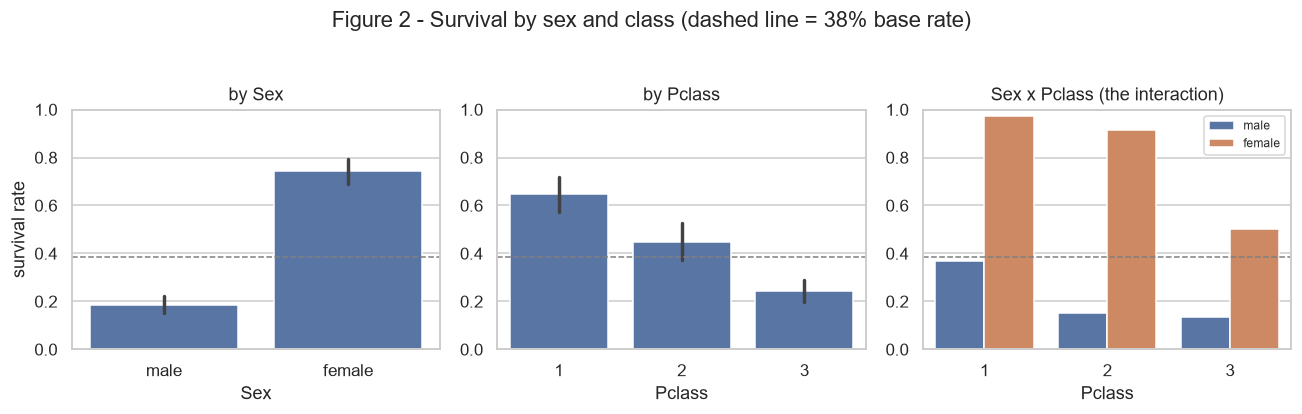

mean               size         
Pclass      1      2      3    1   2    3
Sex                                      
female  0.975  0.914  0.500   79  58  116
male    0.370  0.152  0.135   92  92  275

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

sns.barplot(data=df, x="Sex", y=TARGET_COLUMN, errorbar=("ci", 95), ax=axes[0])
axes[0].set_title("by Sex")
axes[0].set_ylabel("survival rate")

sns.barplot(data=df, x="Pclass", y=TARGET_COLUMN, errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("by Pclass")
axes[1].set_ylabel("")

sns.barplot(data=df, x="Pclass", y=TARGET_COLUMN, hue="Sex", errorbar=None, ax=axes[2])
axes[2].set_title("Sex x Pclass (the interaction)")
axes[2].set_ylabel("")
axes[2].legend(title=None, fontsize=8)

for ax in axes:
    ax.set_ylim(0, 1)
    ax.axhline(base_rate, color="grey", ls="--", lw=1)

fig.suptitle("Figure 2 - Survival by sex and class (dashed line = 38% base rate)", y=1.04)
plt.show()

pivot = df.pivot_table(
    index="Sex", columns="Pclass", values=TARGET_COLUMN, aggfunc=["mean", "size"]
)
display(pivot.round(3))

**Finding.** Sex is overwhelmingly the strongest single predictor (~74% of women survived
versus ~19% of men), and class matters a great deal on top of it. Critically, the third panel
shows the effects are **not additive**: a third-class woman fares worse than a first-class
woman by a far larger margin than the equivalent gap among men. Note too that `Pclass` is not
linear — the 1st-to-2nd gap is much wider than the 2nd-to-3rd gap.

**Decision.**
- `Pclass` is treated as **categorical**, not as a number. Three levels cost nothing and a
  linear coefficient would misrepresent the spacing.
- Because the interaction is real, a plain linear model is at a genuine disadvantage here.
  This is exactly why the project trains a ladder: `fast` (linear, cannot represent the
  interaction without explicit crosses), `deep` (MLP, learns it), and `gbdt` (trees, model
  interactions natively). Comparing them *measures* how much the interaction is worth.

---

## 6. Age, and why `Title` is how we impute it

**Question.** 20% of ages are missing. What is the least damaging way to fill them?

**Analysis.** *(Figure 3 of 7)*

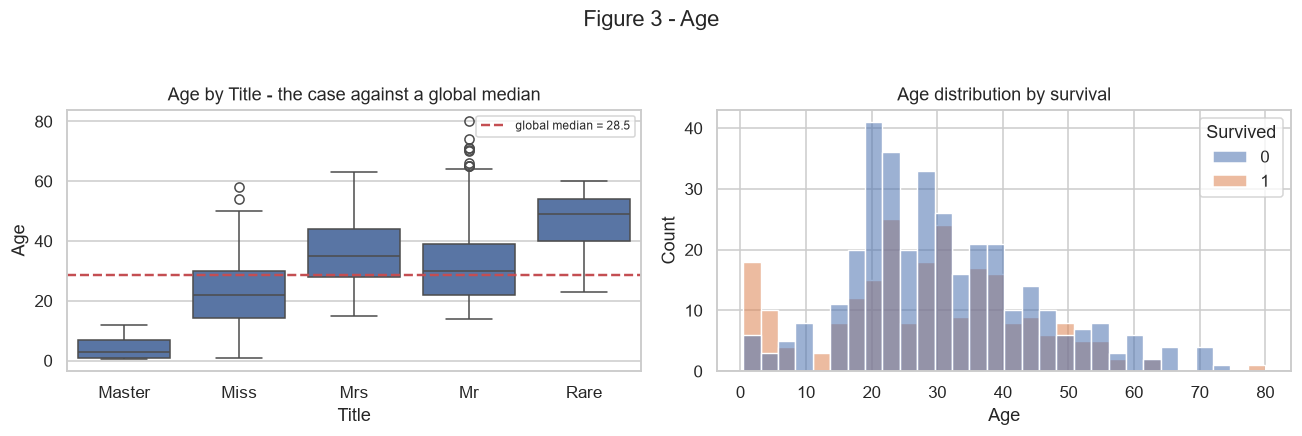

,median,mean,count,missing_age
Title,,,,
Master,3.0,4.2,28,3
Miss,22.0,21.6,118,26
Mr,30.0,32.4,318,94
Mrs,35.0,36.1,94,13
Rare,49.0,46.1,17,1



survival rate, age < 10 : 0.640
survival rate, everyone : 0.383


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

order = ["Master", "Miss", "Mrs", "Mr", "Rare"]
order = [t for t in order if t in df["Title"].unique()]
sns.boxplot(data=df, x="Title", y="Age", order=order, ax=axes[0])
global_median = df["Age"].median()
axes[0].axhline(global_median, color="#c44e52", ls="--", lw=1.6,
                label=f"global median = {global_median:.1f}")
axes[0].set_title("Age by Title - the case against a global median")
axes[0].legend(fontsize=8)

sns.histplot(data=df, x="Age", hue=TARGET_COLUMN, bins=30, multiple="layer",
             alpha=0.55, ax=axes[1])
axes[1].set_title("Age distribution by survival")

fig.suptitle("Figure 3 - Age", y=1.04)
plt.show()

age_table = df.groupby("Title")["Age"].agg(["median", "mean", "count"]).round(1)
age_table["missing_age"] = df[df["Age"].isna()].groupby("Title").size()
display(age_table)

children = df[df["Age"] < 10][TARGET_COLUMN].mean()
print(f"\nsurvival rate, age < 10 : {children:.3f}")
print(f"survival rate, everyone : {base_rate:.3f}")

**Finding.** The median age per title ranges from about **3 for `Master`** (the title used for
boys) to about **30 for `Mr`** and higher for `Rare` (which collects `Dr`, `Rev`, `Col`,
`Lady`...). The global median sits near 28.5 — the red dashed line — which is a plausible age
for exactly one of those groups. The right panel shows why this matters: young children
survived at a visibly higher rate than the base rate.

**Decision.** Impute `Age` with the **median for the passenger's `Title`**, falling back to the
global median for titles unseen during fitting. Filling with 28.5 globally would hand an adult
age to every boy with an unrecorded age and quietly erase the "children first" signal — the
second strongest effect in the data after sex.

*Alternative considered:* a regression imputer using the other columns. Rejected — it adds a
second model to serialise, a second thing to explain, and another surface for leakage, in
exchange for very little on 712 rows.

`Title` itself is kept as a model feature too: it compresses sex × age × social status into
five levels, and anything outside the four common titles collapses to `Rare`, so an unseen
title at inference never breaks anything.

---

## 7. Fare is badly skewed

**Question.** Can `Fare` be used as-is?

**Analysis.** *(Figure 4 of 7)*

17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


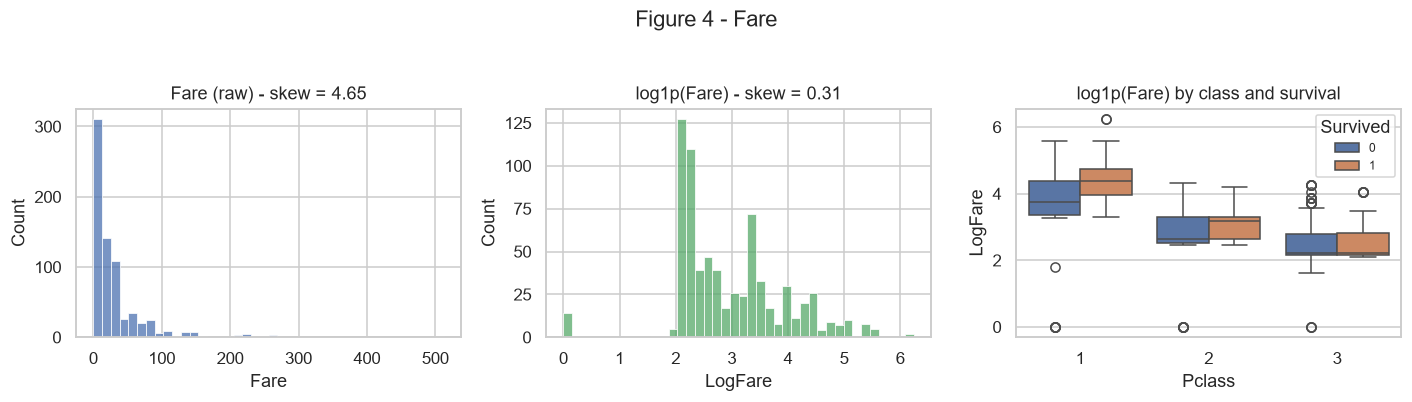

count    712.00
mean      31.82
std       48.06
min        0.00
25%        7.90
50%       14.45
75%       31.00
max      512.33

zero fares : 14  <- why log1p, not log
max / median ratio : 35.4x


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

sns.histplot(df["Fare"], bins=40, ax=axes[0], color="#4c72b0")
axes[0].set_title(f"Fare (raw) - skew = {df['Fare'].skew():.2f}")

sns.histplot(df["LogFare"], bins=40, ax=axes[1], color="#55a868")
axes[1].set_title(f"log1p(Fare) - skew = {df['LogFare'].skew():.2f}")

sns.boxplot(data=df, x="Pclass", y="LogFare", hue=TARGET_COLUMN, ax=axes[2])
axes[2].set_title("log1p(Fare) by class and survival")
axes[2].legend(title="Survived", fontsize=8)

fig.suptitle("Figure 4 - Fare", y=1.04)
plt.show()

print(df["Fare"].describe().round(2).to_string())
print(f"\nzero fares : {(df['Fare'] == 0).sum()}  <- why log1p, not log")
print(f"max / median ratio : {df['Fare'].max() / df['Fare'].median():.1f}x")

**Finding.** Raw `Fare` has a long right tail — the most expensive ticket is roughly 35× the
median — so a handful of first-class fares would dominate a linear coefficient. `log1p`
compresses the skew substantially. There are also **fares of exactly 0** in the data, which is
precisely why `log1p` is used rather than `log`. The third panel shows fare still separates
survivors *within* each class, so it is not merely a proxy for `Pclass`.

**Decision.**
- Model `log1p(Fare)`, not `Fare`.
- **Keep the outliers.** They are real tickets bought by real passengers, not measurement
  errors, and the log transform already limits their leverage. Removing them would be fitting
  the data to the model.
- Impute missing fares with the **training-split median**, then recompute `LogFare` from the
  imputed value — never impute the log column directly, because
  `log1p(median(fare)) != median(log1p(fare))`.

---

## 8. Family size is not monotonic

**Question.** Do `SibSp` and `Parch` help, and in what form?

**Analysis.** *(Figure 5 of 7)*

17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:01:20 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


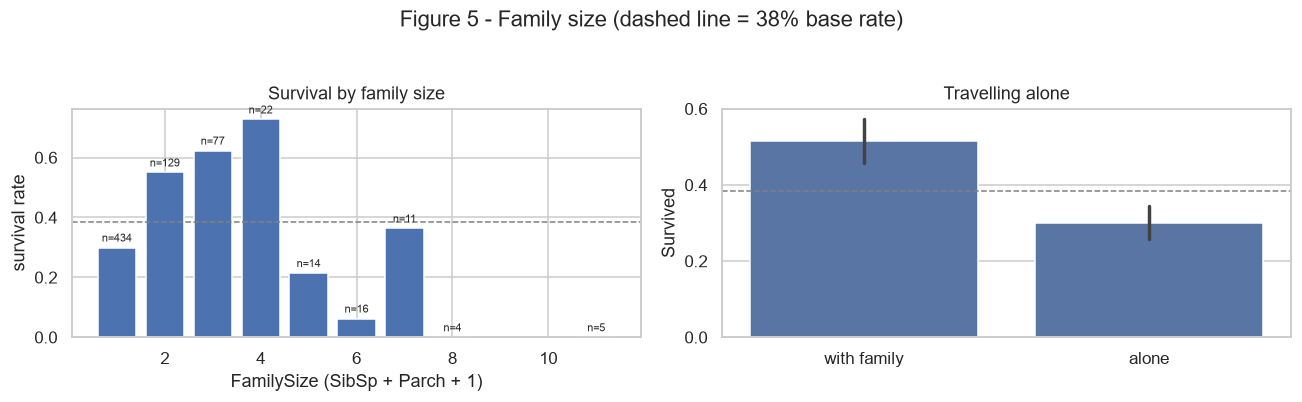

,mean,size
FamilySize,,
1,0.300,434
2,0.550,129
3,0.623,77
4,0.727,22
5,0.214,14
6,0.062,16
7,0.364,11
8,0.000,4
11,0.000,5


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

family_stats = df.groupby("FamilySize")[TARGET_COLUMN].agg(["mean", "size"])
axes[0].bar(family_stats.index, family_stats["mean"], color="#4c72b0")
axes[0].axhline(base_rate, color="grey", ls="--", lw=1)
axes[0].set_xlabel("FamilySize (SibSp + Parch + 1)")
axes[0].set_ylabel("survival rate")
axes[0].set_title("Survival by family size")
for x, (rate, n) in family_stats.iterrows():
    axes[0].text(x, rate + 0.02, f"n={int(n)}", ha="center", fontsize=7)

sns.barplot(data=df, x="IsAlone", y=TARGET_COLUMN, errorbar=("ci", 95), ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["with family", "alone"])
axes[1].axhline(base_rate, color="grey", ls="--", lw=1)
axes[1].set_xlabel("")
axes[1].set_title("Travelling alone")

fig.suptitle("Figure 5 - Family size (dashed line = 38% base rate)", y=1.04)
plt.show()

display(family_stats.round(3))

**Finding.** Survival peaks for families of **2 to 4** and collapses at both ends: solo
travellers did poorly, and so did very large families (though the counts there are small — note
the `n=` labels, several groups have under 10 passengers, so those bars are noisy).

**Decision.**
- Use **`FamilySize` = SibSp + Parch + 1**, and drop `SibSp`/`Parch` as separate features. The
  pattern is a function of the total, and keeping all three only adds collinearity for the
  linear model.
- Keep **`IsAlone`** as an explicit binary even though it is derivable from `FamilySize`. The
  drop at exactly size 1 is a *step*, and a linear model cannot represent a step from a single
  continuous input.

---

## 9. Redundancy among the final features

**Question.** Does the final feature set contain anything redundant?

**Analysis.** *(Figure 6 of 7)*

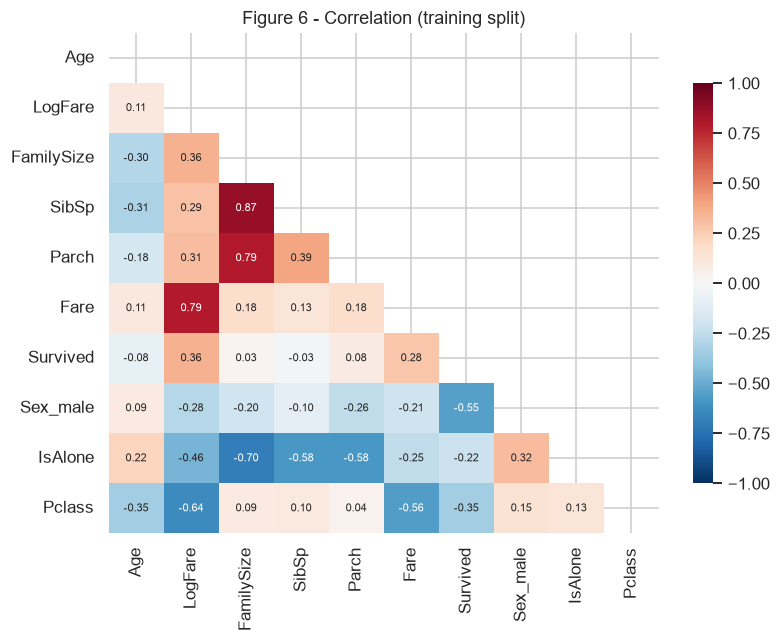

Correlation with Survived, strongest first:
Sex_male      0.549
LogFare       0.355
Pclass        0.348
Fare          0.275
IsAlone       0.216
Age           0.084
Parch         0.084
FamilySize    0.027
SibSp         0.026


In [10]:
numeric_view = df[["Age", "LogFare", "FamilySize", "SibSp", "Parch", "Fare", TARGET_COLUMN]].copy()
numeric_view["Sex_male"] = (df["Sex"] == "male").astype(int)
numeric_view["IsAlone"] = df["IsAlone"]
numeric_view["Pclass"] = df["Pclass"]

corr = numeric_view.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7}, ax=ax)
ax.set_title("Figure 6 - Correlation (training split)")
plt.show()

print("Correlation with Survived, strongest first:")
print(corr[TARGET_COLUMN].drop(TARGET_COLUMN).abs().sort_values(ascending=False).round(3).to_string())

**Finding.** `Sex` dominates every numeric correlation. `FamilySize` is, by construction,
strongly correlated with both `SibSp` and `Parch` — confirming they are redundant once the
total exists. `LogFare` and `Pclass` are strongly related but not interchangeable, consistent
with the within-class fare spread seen in Figure 4.

**Decision.** Final feature set, which is exactly what
`titanic.preprocessing.DEFAULT_NUMERIC_COLS` and `DEFAULT_CATEGORICAL_COLS` declare:

- **numeric (standardised):** `Age`, `LogFare`, `FamilySize`
- **categorical (indexed, `<UNK>` = 0):** `Pclass`, `Sex`, `Embarked`, `Title`, `Deck`, `IsAlone`

Note that correlation only measures *linear* association, so a low value here is not evidence
that a feature is useless to a tree or a neural network — it is used as a redundancy check, not
as feature selection.

---

## 10. A classical sanity check — what score should we expect?

**Question.** Before writing any PyTorch, what is a *reasonable* score on this data? Without
this number, we cannot tell a working neural network from a broken one.

**Analysis.** 5-fold stratified cross-validation **inside the training split**, using the real
`Preprocessor` refitted within every fold — so this estimate is itself leak-free.
*(Figure 7 of 7.)*

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

from titanic.preprocessing import Preprocessor

y = df[TARGET_COLUMN].to_numpy()
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "LogisticRegression": lambda: LogisticRegression(max_iter=1000, random_state=42),
    "HistGradientBoosting": lambda: HistGradientBoostingClassifier(
        max_iter=300, early_stopping=True, random_state=42
    ),
}
results: dict[str, dict[str, list[float]]] = {
    name: {"auc": [], "acc": []} for name in candidates
}

for fold_train_idx, fold_val_idx in folds.split(df, y):
    fold_train, fold_val = df.iloc[fold_train_idx], df.iloc[fold_val_idx]

    # Refit the preprocessor inside every fold. Fitting it once outside the
    # loop would leak each fold's validation rows into the imputation and
    # scaling statistics - a small effect here, but the exact mistake this
    # project is built to avoid.
    pre = Preprocessor().fit(fold_train)
    xtr = np.hstack(pre.transform(fold_train))
    xva = np.hstack(pre.transform(fold_val))

    for name, build in candidates.items():
        model = build().fit(xtr, y[fold_train_idx])
        prob = model.predict_proba(xva)[:, 1]
        results[name]["auc"].append(roc_auc_score(y[fold_val_idx], prob))
        results[name]["acc"].append(accuracy_score(y[fold_val_idx], prob >= 0.5))

cv_table = pd.DataFrame(
    {
        name: {
            "roc_auc_mean": np.mean(scores["auc"]),
            "roc_auc_std": np.std(scores["auc"]),
            "accuracy_mean": np.mean(scores["acc"]),
            "accuracy_std": np.std(scores["acc"]),
        }
        for name, scores in results.items()
    }
).T.round(4)
display(cv_table)

17:01:21 | INFO    | titanic.preprocessing | Preprocessor fitted on 569 rows: 3 numeric, 6 categorical (cardinalities [4, 3, 4, 6, 10, 3])


17:01:21 | INFO    | titanic.preprocessing | Preprocessor fitted on 569 rows: 3 numeric, 6 categorical (cardinalities [4, 3, 4, 6, 10, 3])


17:01:21 | INFO    | titanic.preprocessing | Preprocessor fitted on 570 rows: 3 numeric, 6 categorical (cardinalities [4, 3, 4, 6, 9, 3])


17:01:21 | INFO    | titanic.preprocessing | Preprocessor fitted on 570 rows: 3 numeric, 6 categorical (cardinalities [4, 3, 4, 6, 10, 3])


17:01:21 | INFO    | titanic.preprocessing | Preprocessor fitted on 570 rows: 3 numeric, 6 categorical (cardinalities [4, 3, 4, 6, 10, 3])


,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
LogisticRegression,0.8623,0.0248,0.7964,0.0211
HistGradientBoosting,0.8916,0.0139,0.8343,0.0260


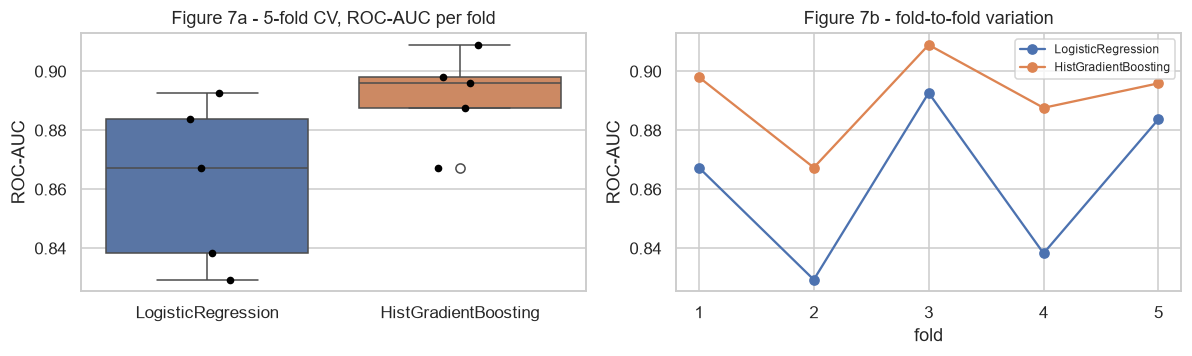

fold-to-fold ROC-AUC spread across everything: 0.080

Expectation band for Phase 3: a correctly implemented model should land near
ROC-AUC 0.86-0.89 on the held-out split.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

auc_frame = pd.DataFrame({name: scores["auc"] for name, scores in results.items()})
sns.boxplot(data=auc_frame, ax=axes[0])
sns.stripplot(data=auc_frame, color="black", size=5, ax=axes[0])
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Figure 7a - 5-fold CV, ROC-AUC per fold")

for name, scores in results.items():
    axes[1].plot(range(1, 6), scores["auc"], marker="o", label=name)
axes[1].set_xlabel("fold")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_xticks(range(1, 6))
axes[1].set_title("Figure 7b - fold-to-fold variation")
axes[1].legend(fontsize=8)

plt.show()

spread = auc_frame.max().max() - auc_frame.min().min()
print(f"fold-to-fold ROC-AUC spread across everything: {spread:.3f}")
print("\nExpectation band for Phase 3: a correctly implemented model should land near")
print(f"ROC-AUC {auc_frame.mean().min():.2f}-{auc_frame.mean().max():.2f} on the held-out split.")

**Finding.** Both classical models land in the same region, and — the more important
observation — the **fold-to-fold spread is larger than the gap between the two models**. On
712 rows, a difference of one or two AUC points between two reasonable models is not
distinguishable from sampling noise.

**Decision.** Two consequences for the rest of the project:

1. **An expectation band.** Any PyTorch model that scores far below this band has a bug, not a
   modelling problem. Any model that scores far *above* it has leaked. This number is the
   sanity check Phase 3 is measured against.
2. **A tiny hyperparameter grid.** Since the CV standard deviation exceeds most between-config
   differences, a large search would mostly be fitting noise. The `deep` model gets an
   8-point grid (hidden size × dropout × weight decay) and `gbdt` a 4-point grid — no more.
   Everything is selected by cross-validation **inside** the training split; the held-out set
   is never used to choose anything.

---

## 11. Conclusions

**Final feature set** — implemented in `titanic.features` and `titanic.preprocessing`:

| kind | features | treatment |
|---|---|---|
| numeric | `Age`, `LogFare`, `FamilySize` | standardised with training-split mean/std |
| categorical | `Pclass`, `Sex`, `Embarked`, `Title`, `Deck`, `IsAlone` | indexed, `<UNK>` = 0 |

**Imputation, all fitted on the training split and serialised to JSON:** `Age` → median per
`Title` (global median as fallback); `Fare` → training median, with `LogFare` recomputed
afterwards; `Embarked` → mode; `Cabin` → `Deck`, missing becomes the level `U`.

**Deliberately excluded:** `SibSp`/`Parch` (redundant once `FamilySize` exists),
`TicketGroupSize` and `FarePerPerson` (batch-dependent — train/serve skew plus cross-row label
leakage), `AgeBin` (any model can learn the threshold from `Age`).

**What this dataset is like, and what to expect.**

- It is **small** (712 training rows) and **low-dimensional** (9 features). The dominant signal
  is low-order: sex, then class, then age, then family size.
- Consequently, **a neural network is not expected to win here.** Gradient-boosted trees model
  thresholds and interactions natively and need far less data to find them; an MLP has to learn
  the same structure from scratch on 712 examples. The linear model may well land inside the
  MLP's confidence interval.
- That outcome is not a failure of the assignment — it is the finding. The project therefore
  reports **every model with bootstrap confidence intervals** and states plainly whether the
  models are distinguishable at all, rather than declaring a winner on a difference smaller
  than the noise.

**Metrics.** Accuracy alone is inadequate at a 38% base rate. The project reports accuracy,
precision, recall, F1, ROC-AUC, PR-AUC and Brier score, each with a 95% bootstrap CI, plus a
confusion matrix and a threshold sweep.

**Next:** `src/titanic/models.py` and `train.py` (Phase 3).